In [1]:
import xarray as xr
from xcube.core.store import new_data_store
import matplotlib.pyplot as plt
import pystac_client
import geopandas as gpd
import fsspec
import planetary_computer

In [7]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

In [8]:
search = catalog.search(
    collections=["sentinel-3-slstr-lst-l2-netcdf"],
    intersects={"type": "Point", "coordinates": [8, 52]},
    datetime=["2020-07-31", "2020-07-31"]
)
items = list(search.items())
items

[<Item id=S3A_SL_2_LST_20200731T213603_20200731T213903_0179_061_129_0720>,
 <Item id=S3B_SL_2_LST_20200731T205637_20200731T205937_0179_041_371_0720>,
 <Item id=S3A_SL_2_LST_20200731T101008_20200731T101308_0179_061_122_1980>,
 <Item id=S3B_SL_2_LST_20200731T093342_20200731T093642_0179_041_364_2160>]

In [9]:
items[0]

<Item id=S3A_SL_2_LST_20200731T213603_20200731T213903_0179_061_129_0720>

In [13]:
items[1]

<Item id=S3B_SL_2_LST_20200731T205637_20200731T205937_0179_041_371_0720>

In [14]:
items[2]

<Item id=S3A_SL_2_LST_20200731T101008_20200731T101308_0179_061_122_1980>

In [11]:
dataset = xr.open_dataset(fsspec.open(items[0].assets["lst-in"].href).open())
dataset

<xarray.Dataset> Size: 20MB
Dimensions:                 (rows: 1200, columns: 1500, orphan_pixels: 187)
Dimensions without coordinates: rows, columns, orphan_pixels
Data variables:
    LST                     (rows, columns) float32 7MB ...
    LST_orphan              (rows, orphan_pixels) float32 898kB ...
    LST_uncertainty         (rows, columns) float32 7MB ...
    LST_uncertainty_orphan  (rows, orphan_pixels) float32 898kB ...
    exception               (rows, columns) int16 4MB ...
    exception_orphan        (rows, orphan_pixels) int16 449kB ...
Attributes: (12/16)
    absolute_orbit_number:  23202
    comment:                 
    contact:                eosupport@copernicus.esa.int
    creation_time:          20200802T030250Z
    history:                  2020-08-02T03:02:50Z: PUGCoreProcessor /data/ip...
    institution:            LN2
    ...                     ...
    source:                 IPF-SL-2 06.16
    start_offset:           45245
    start_time:             2020-07-31T21:36:02.830931Z
    stop_time:              2020-07-31T21:39:02.522651Z
    title:                  SLSTR Level 2 Product, Land Surface Temperature m...
    track_offset:           998

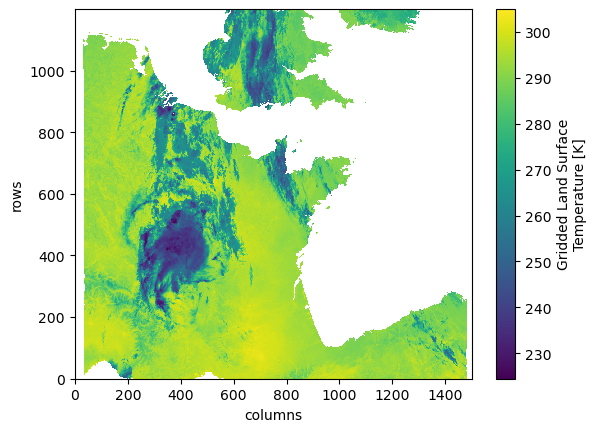

In [12]:
dataset.LST.plot()

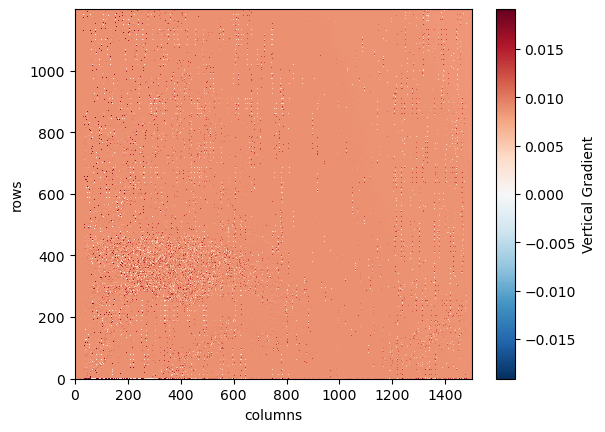

In [33]:
lon_grad = dataset.latitude_in.differentiate("rows").rename("Vertical Gradient")
lon_grad.plot()

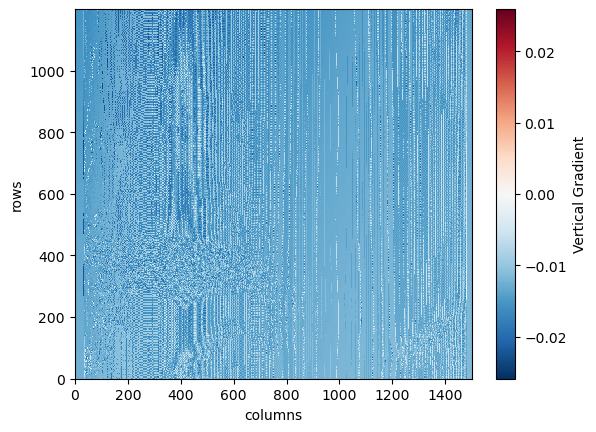

In [34]:
lon_grad = dataset.longitude_in.differentiate("columns").rename("Vertical Gradient")
lon_grad.plot()

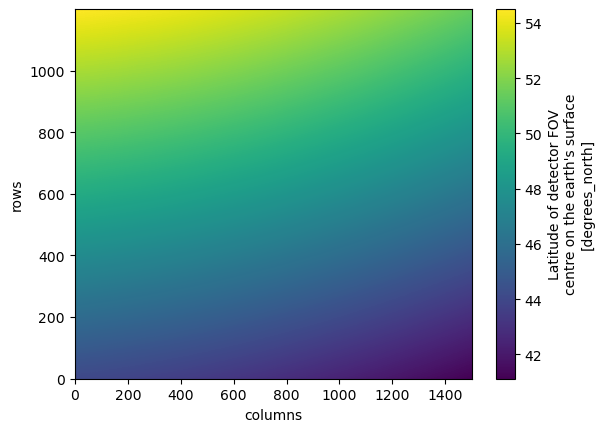

In [28]:
dataset.latitude_in.plot()

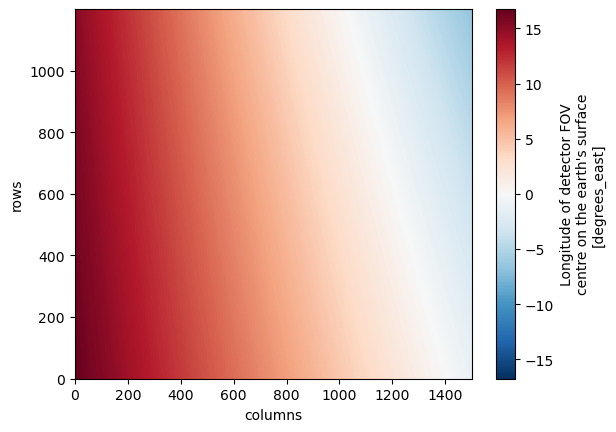

In [29]:
dataset.longitude_in.plot()

In [15]:
features = [item.to_dict() for item in items]
gdf = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")

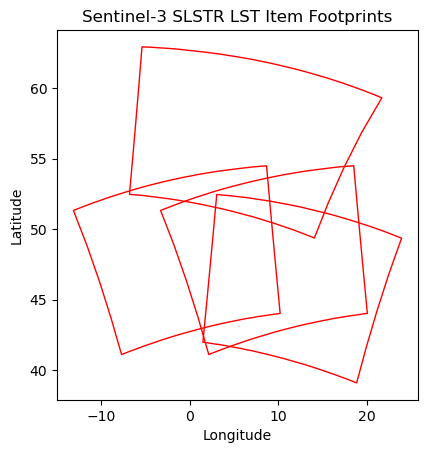

In [16]:
gdf.plot(facecolor="none", edgecolor="red", linewidth=1)
plt.title("Sentinel-3 SLSTR LST Item Footprints")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [3]:
store = new_data_store("stac-pc")

In [4]:
descriptors = list(
    store.search_data(
        collections=["sentinel-3-slstr-lst-l2-netcdf"],
        bbox=[8, 52, 8.1, 52.1],
        time_range=["2020-07-31", "2020-07-31"],
    )
)
len(descriptors)

5

<xarray.Dataset> Size: 11MB
Dimensions:      (lon: 1763, lat: 1553)
Coordinates:
  * lon          (lon) float64 14kB -13.08 -13.06 -13.05 ... 10.18 10.2 10.21
  * lat          (lat) float64 12kB 54.49 54.48 54.48 ... 41.13 41.12 41.11
    spatial_ref  int64 8B 0
Data variables:
    LST          (lat, lon) float32 11MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Attributes: (12/16)
    absolute_orbit_number:  23202
    comment:                
    contact:                eosupport@copernicus.esa.int
    creation_time:          20200802T030250Z
    history:                2020-08-02T03:02:50Z: PUGCoreProcessor /data/ipf-...
    institution:            LN2
    ...                     ...
    source:                 IPF-SL-2 06.16
    start_offset:           45245
    start_time:             2020-07-31T21:36:02.830931Z
    stop_time:              2020-07-31T21:39:02.522651Z
    title:                  SLSTR Level 2 Product, Land Surface Temperature m...
    track_offset:           

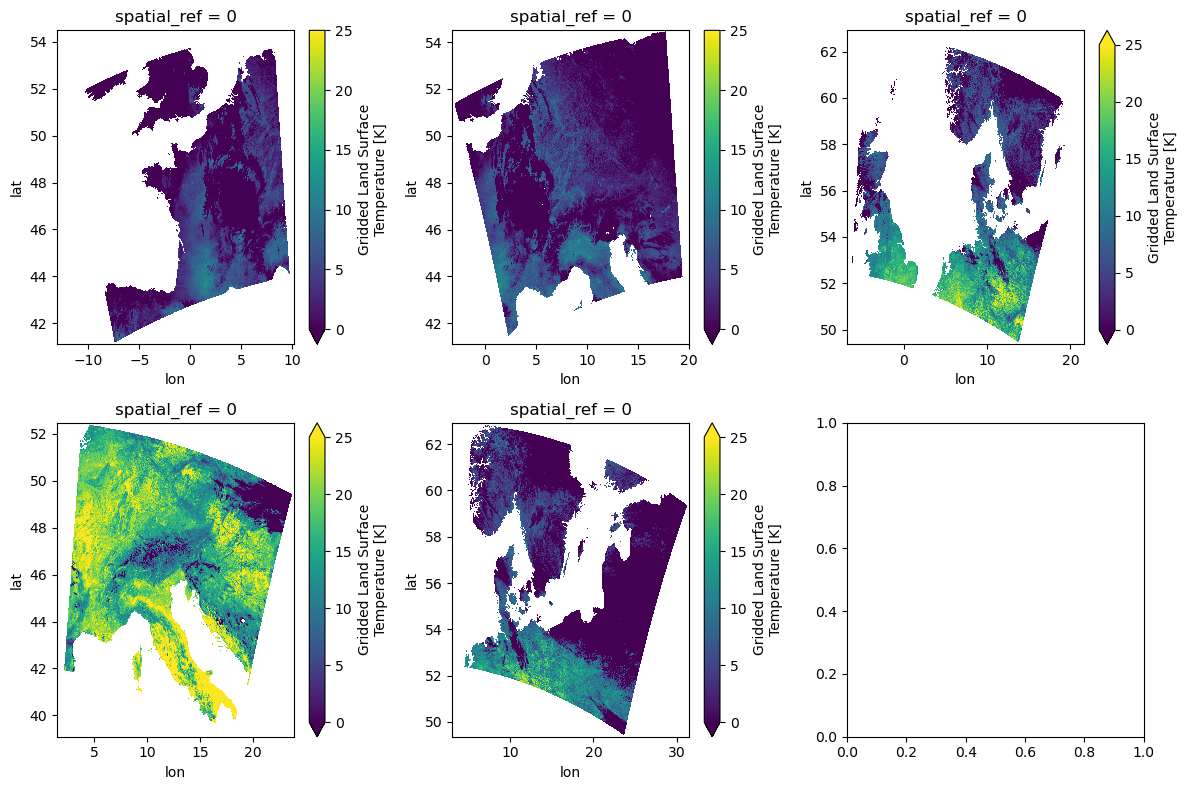

In [5]:
fig, _ax = plt.subplots(2, 3, figsize=(12, 8))
ax = _ax.flatten()

for i, descriptor in enumerate(descriptors):
    ds = store.open_data(descriptor.data_id)
    print(ds)
    ds.LST.plot(ax=ax[i], vmin=0, vmax=25)

plt.tight_layout()